# Assignment 13 - Data Gathering, Preprocessing & EDA

## Dataset Source
Kaggle Superstore Dataset

https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

## TMDB API
API Endpoint:
`https://api.themoviedb.org/3/movie/popular`

Library Used: `requests`

## Target Column Selection

**Target Column:** Sales

**Reason:** I selected Sales as the target column because it is a numerical column that can be predicted using the remaining features such as Category, Region, Quantity, Discount and Segment.

## Observations

1. Sales contains a few high-value outliers.
2. Technology category has higher sales than the other categories.
3. Sales and Profit show a positive relationship.
4. Very few missing values are present after cleaning.
5. Duplicate rows were removed during preprocessing.

# A13 - GenAI Notebook

This notebook shows the same workflow used in the assignment scripts:

- Task 1: CSV, JSON, and SQLite loading
- Task 2: TMDB movie data
- Task 3: feature preparation
- Task 4: EDA and insights

In [1]:
from pathlib import Path
import json
import os
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'superstore_final_dataset.csv').exists():
    candidate_dir = BASE_DIR / 'A13-GenAI'
    if (candidate_dir / 'superstore_final_dataset.csv').exists():
        BASE_DIR = candidate_dir

CSV_PATH = BASE_DIR / 'superstore_final_dataset.csv'
JSON_PATH = BASE_DIR / 'products.json'
TMDB_CSV_PATH = BASE_DIR / 'tmdb_movies.csv'
SQLITE_PATH = BASE_DIR / 'sample.db'
OUTPUT_DIR = BASE_DIR / 'eda_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Task 1: load CSV, JSON, and SQLite data
csv_df = pd.read_csv(CSV_PATH, encoding='unicode_escape')
print('CSV shape:', csv_df.shape)
print(csv_df.head())

if JSON_PATH.exists():
    json_df = pd.read_json(JSON_PATH)
else:
    json_df = pd.DataFrame([
        {'Product': 'Laptop', 'Price': 65656, 'Category': 'Electronics'},
        {'Product': 'Keyboard', 'Price': 1555, 'Category': 'Accessories'},
        {'Product': 'Mouse', 'Price': 579, 'Category': 'Accessories'},
        {'Product': 'Monitor', 'Price': 25639, 'Category': 'Electronics'},
    ])
print('JSON data:')
print(json_df)

connection = sqlite3.connect(SQLITE_PATH)
cursor = connection.cursor()
cursor.execute('CREATE TABLE IF NOT EXISTS employees(id INTEGER PRIMARY KEY, name TEXT, department TEXT, salary INTEGER)')
cursor.execute('DELETE FROM employees')
cursor.executemany('INSERT INTO employees VALUES (?, ?, ?, ?)', [
    (1, 'John', 'HR', 35000),
    (2, 'David', 'Sales', 42000),
    (3, 'Alice', 'IT', 55000),
    (4, 'Sam', 'Finance', 47000),
    (5, 'Emma', 'Marketing', 39000),
])
connection.commit()
employee_df = pd.read_sql_query('SELECT * FROM employees', connection)
print('SQLite data:')
print(employee_df)
connection.close()

CSV shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  

In [3]:
# Task 2: TMDB movie data
if TMDB_CSV_PATH.exists():
    tmdb_df = pd.read_csv(TMDB_CSV_PATH)
    print('Loaded TMDB CSV from disk.')
else:
    api_key = os.getenv('TMDB_API_KEY')
    if api_key:
        response = requests.get(
            'https://api.themoviedb.org/3/movie/popular',
            params={'api_key': api_key, 'language': 'en-US', 'page': 1},
            timeout=30,
        )
        response.raise_for_status()
        movies = response.json().get('results', [])
        movie_rows = []
        for movie in movies:
            movie_rows.append({
                'Title': movie.get('title'),
                'Release Date': movie.get('release_date'),
                'Rating': movie.get('vote_average'),
                'Popularity': movie.get('popularity'),
                'Language': movie.get('original_language'),
            })
        tmdb_df = pd.DataFrame(movie_rows)
        tmdb_df.to_csv(TMDB_CSV_PATH, index=False)
        print('Fetched TMDB data and saved tmdb_movies.csv.')
    else:
        tmdb_df = pd.DataFrame()
        print('TMDB_API_KEY is not set, so no refresh was made in the notebook.')

print(tmdb_df.head())

Loaded TMDB CSV from disk.
            Title Release Date  Rating  Popularity Language
0       Obsession   2026-05-13   8.261    722.1192       en
1     Toy Story 5   2026-06-17   7.400    658.6359       en
2  Disclosure Day   2026-06-10   6.684    496.6377       en
3       Backrooms   2026-05-27   6.800    466.6709       en
4     Scary Movie   2026-06-03   5.405    462.1724       en


In [4]:
# Task 3: feature preparation
df = csv_df.copy()
df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False)
print('I am using sales as the target because it is the numeric outcome I want to compare against other columns.')
encoded_df = pd.get_dummies(df, columns=['category', 'region', 'segment'])
target = encoded_df['sales']
features = encoded_df.drop(columns=['sales'])
print('Feature shape:', features.shape)
print('Target preview:')
print(target.head())

I am using sales as the target because it is the numeric outcome I want to compare against other columns.
Feature shape: (9994, 27)
Target preview:
0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: sales, dtype: float64


Sales mean: 229.86
Sales median: 54.49
Sales/profit correlation: 0.479
Technology profit: 145454.95
Office Supplies profit: 122490.8
Furniture profit: 18451.27
Negative profit rows: 1871
High discount rows: 922


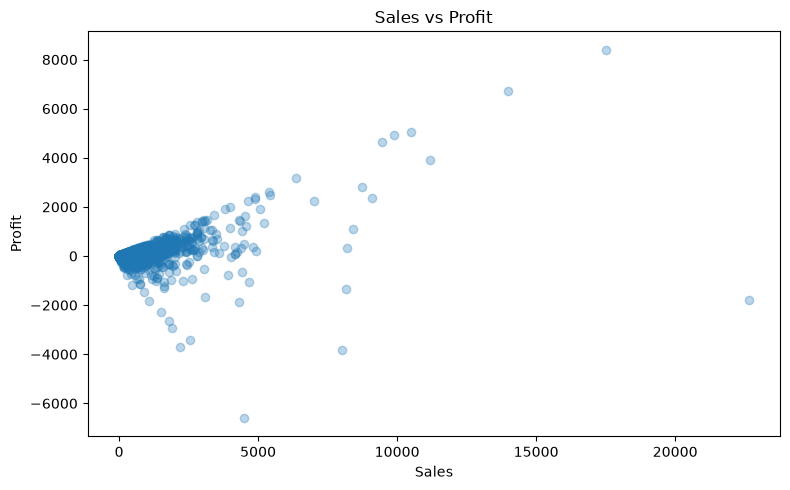

In [5]:
# Task 4: EDA and insights
sales_mean = df['sales'].mean()
sales_median = df['sales'].median()
profit_corr = df[['sales', 'profit', 'quantity', 'discount']].corr()
technology_profit = df.loc[df['category'] == 'Technology', 'profit'].sum()
office_profit = df.loc[df['category'] == 'Office Supplies', 'profit'].sum()
furniture_profit = df.loc[df['category'] == 'Furniture', 'profit'].sum()
negative_profit_rows = int((df['profit'] < 0).sum())
high_discount_rows = int((df['discount'] >= 0.5).sum())

print('Sales mean:', round(sales_mean, 2))
print('Sales median:', round(sales_median, 2))
print('Sales/profit correlation:', round(profit_corr.loc['sales', 'profit'], 3))
print('Technology profit:', round(technology_profit, 2))
print('Office Supplies profit:', round(office_profit, 2))
print('Furniture profit:', round(furniture_profit, 2))
print('Negative profit rows:', negative_profit_rows)
print('High discount rows:', high_discount_rows)

plt.figure(figsize=(8, 5))
plt.scatter(df['sales'], df['profit'], alpha=0.3)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

What I learned:

I learned how to load data from different sources, prepare features for analysis, and turn charts into numeric observations. The TMDB step also shows why saving the API output to a CSV is useful for repeatable work.